# COSC 325 – Introduction to Machine Learning, Spring 2026
## Final Project: STUDENT PERFORMANCE PREDICTION

**Student Names:** Kaitlin Sloan, Praneetha Voona, Manihams Suraparaju, 
Joshua Grewe, Justin Gurkin


---

# Part 1- Data Loading and Preproccessing

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (semicolon-separated)
data = pd.read_csv("student/student-mat.csv", sep=";")
data.columns = data.columns.str.strip()

data.columns
data.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Step 1: Check to make sure the dataset has no missing values and is clean:

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


<Axes: xlabel='G3', ylabel='count'>

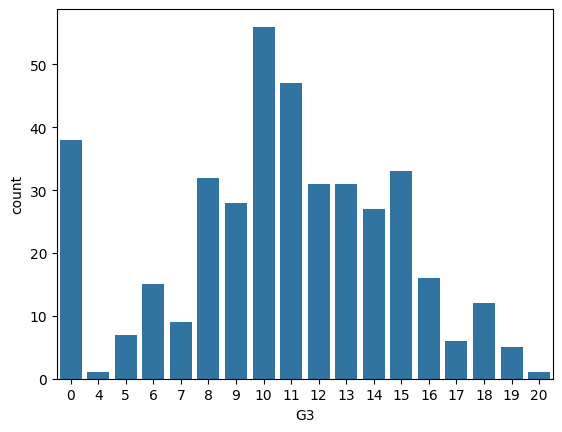

In [2]:
print(data.isnull().sum())
data.describe()
sns.countplot(x=data["G3"])


The output of data.isnull().sum() shows that every column has 0 missing values. This confirms that the dataset is already clean and we can proceed with preprocessing.
The Above graph shows the disrebution of values that exist.


## Step 2: Create Pass/Fail Label and drop G1 and G2

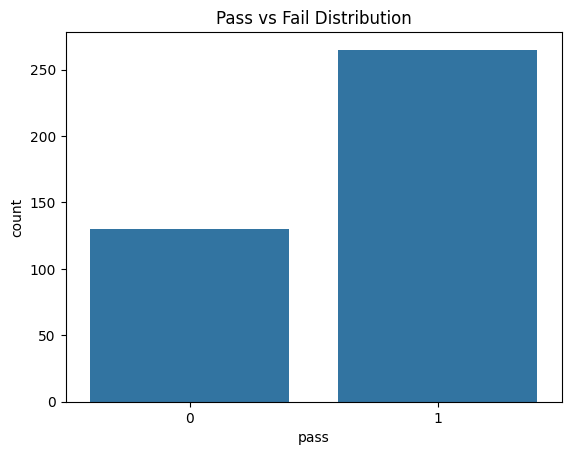

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G3', 'pass'],
      dtype='object')


In [3]:
data["pass"] = (data["G3"] >= 10).astype(int)
plt.clf()
sns.countplot(x=data["pass"])
plt.title("Pass vs Fail Distribution")

plt.show()

#drop g1 and g2
data_no_leak = data.drop(columns=["G1", "G2"])
print(data_no_leak.columns)


## Step 3: Build Preproccessing Pipeline and TrainTest Split + Logistic Regression

In [4]:
# define features and label first so column lists match the feature dataframe
X = data_no_leak.drop(columns=["pass"])
y = data_no_leak["pass"]

# derive categorical/numeric column lists from X (not from data_no_leak) so they match
catagorical = X.select_dtypes(include="object").columns
numeric = X.select_dtypes(include=["int64", "float64"]).columns

# ensure OneHotEncoder ignores unknown categories in test set
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), catagorical),
        ("num", StandardScaler(), numeric),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train_prep = preprocess.fit_transform(X_train)
X_test_prep = preprocess.transform(X_test)

logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train_prep, y_train)

LogisticRegression(max_iter=500)

## Step 5: Evaluate Baseline Model

F1 Score: 0.9346
ROC-AUC: 0.9790

Confusion Matrix (raw counts):
[[22  4]
 [ 3 50]]


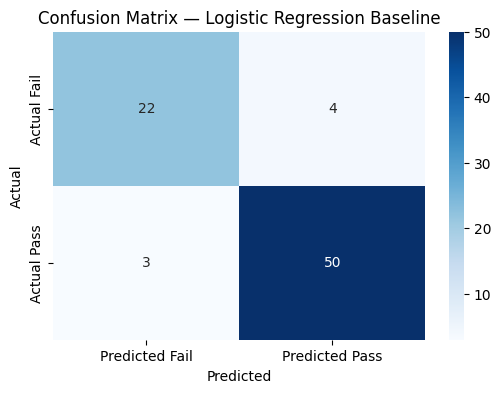

In [5]:
preds = logreg.predict(X_test_prep)
probs = logreg.predict_proba(X_test_prep)[:, 1]

# Scores
f1 = f1_score(y_test, preds)
roc = roc_auc_score(y_test, probs)

print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print("\nConfusion Matrix (raw counts):")
print(confusion_matrix(y_test, preds))

# Pretty confusion matrix
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Fail", "Predicted Pass"],
            yticklabels=["Actual Fail", "Actual Pass"])
plt.title("Confusion Matrix — Logistic Regression Baseline")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Part 2 - Random Forest Pipeline

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

Load dataset (semicolon-separated)

In [7]:
data = pd.read_csv("student/student-mat.csv", sep=";")
data.columns = data.columns.str.strip()

# Step 1: Create Pass/Fail Label and drop G1, G2, AND G3

In [8]:
data["pass"] = (data["G3"] >= 10).astype(int)

Drop G1, G2, and G3 to prevent data leakage (since pass is based on G3)

In [9]:
data_no_leak = data.drop(columns=["G1", "G2", "G3"])
print("Features used for training:")
print(data_no_leak.columns)

Features used for training:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'pass'],
      dtype='object')


Since the dataset uses a numeric grade for G3, we first convert it into a binary pass/fail label using a cutoff of 10, which is the standard passing threshold in the Portuguese school system. We also make sure to drop G1 and G2 alongside G3 — we caught early on that leaving those in would basically be giving the model the answer, since they're just earlier grades for the same class.

# Step 2: Build Preprocessing Pipeline and Train/Test Split

Define features and label

In [10]:
X = data_no_leak.drop(columns=["pass"])
y = data_no_leak["pass"]

Derive categorical/numeric column lists from X

In [11]:
categorical = X.select_dtypes(include="object").columns
numeric = X.select_dtypes(include=["int64", "float64"]).columns

preprocess = ColumnTransformer(
transformers=[
("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
("num", StandardScaler(), numeric),
]
)

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42
)

Preprocess the data

In [12]:
X_train_prep = preprocess.fit_transform(X_train)
X_test_prep = preprocess.transform(X_test)

Extract feature names for the importance plot later

In [13]:
cat_feature_names = preprocess.named_transformers_["cat"].get_feature_names_out(categorical)
feature_names = np.concatenate([cat_feature_names, numeric])

We set up a preprocessing pipeline to handle the mix of categorical and numeric features in the dataset. Categorical columns get One-Hot Encoded and numeric ones are standardized, then we do an 80/20 train/test split with stratification so the pass/fail ratio stays consistent between both sets.

# Step 3: Train Random Forest with Stratified 5-fold CV & Hyperparameter Tuning

In [14]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
'n_estimators': [50, 100, 200],
'max_depth': [None, 5, 10, 15],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4]
}

Stratified 5-fold CV optimizing for F1-score

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)

print("Starting Grid Search CV...")
grid_search.fit(X_train_prep, y_train)

best_rf = grid_search.best_estimator_
print(f"Best Hyperparameters: {grid_search.best_params_}")

Starting Grid Search CV...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}


Instead of just going with default settings, we ran a grid search over several hyperparameters like tree depth, number of estimators, and minimum samples per leaf to find the best combination. We used Stratified 5-Fold CV with F1-score as the target metric since we wanted the model to perform well across both classes, not just the majority one.

# Step 4: Evaluate Tuned Model

In [16]:
preds = best_rf.predict(X_test_prep)
probs = best_rf.predict_proba(X_test_prep)[:, 1]

Scores

In [17]:
f1 = f1_score(y_test, preds)
roc = roc_auc_score(y_test, probs)

print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds))

F1 Score: 0.7603
ROC-AUC: 0.6081

Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.15      0.22        26
           1       0.68      0.87      0.76        53

    accuracy                           0.63        79
   macro avg       0.52      0.51      0.49        79
weighted avg       0.57      0.63      0.58        79



Pretty confusion matrix

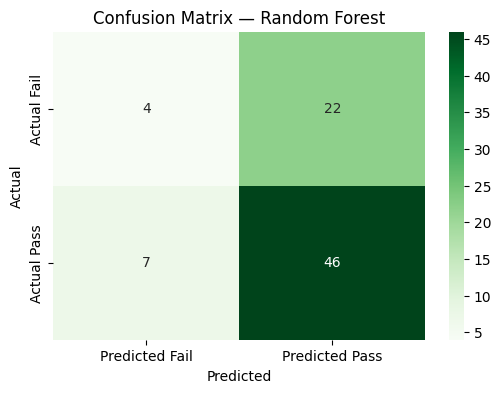

In [18]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
xticklabels=["Predicted Fail", "Predicted Pass"],
yticklabels=["Actual Fail", "Actual Pass"])
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

We evaluated the best model on the test set using F1-score and ROC-AUC to get a sense of both its precision-recall balance and overall classification ability. We also plotted a confusion matrix to see exactly where the model was getting things right or wrong in terms of pass/fail predictions.


# Step 5: Plot Feature Importances (Gini-Based)

In [19]:
importances =best_rf.feature_importances_

Create a DataFrame and sort

In [20]:
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

Plot top 15 features

/var/folders/yc/0b_mrkhd5fng2chkfbwpwr800000gn/T/ipykernel_8568/1377271843.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df.head(15), palette='viridis')


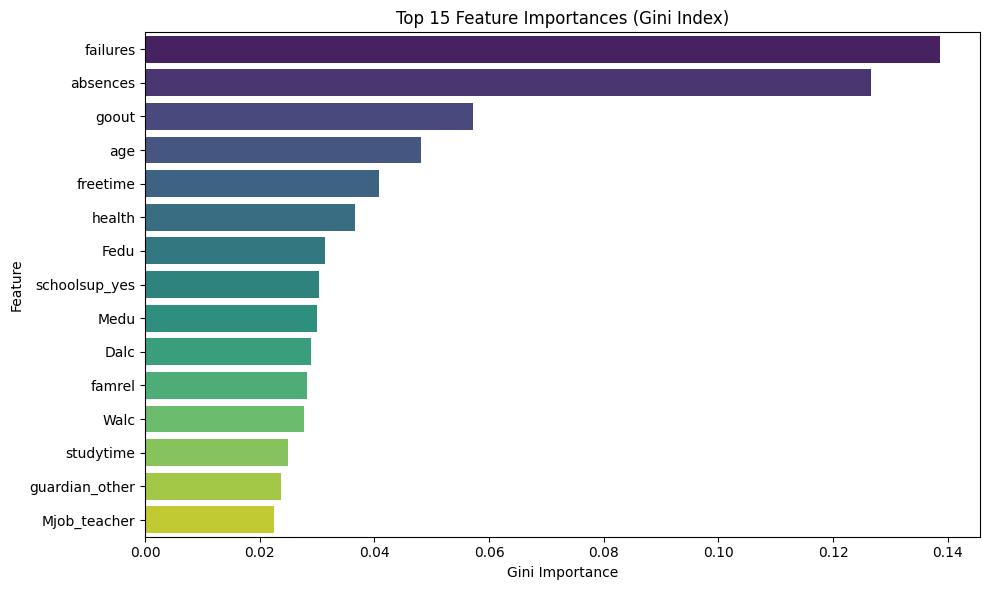

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (Gini Index)')
plt.xlabel('Gini Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

To get a better understanding of what the model actually learned, we pulled the Gini-based feature importances from the trained Random Forest and plotted the top 15. This helped us see which features — whether behavioral, demographic, or school-related — ended up being the most useful for predicting whether a student would pass.

# Part 3 - Gradient Boosting Pipeline

In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
data = pd.read_csv("student/student-mat.csv", sep=";")
data.columns = data.columns.str.strip()

# Step 1: Create two sets one with G1/G2 and one without

In [ ]:
data["pass"] = (data["G3"] >= 10).astype(int)

In [ ]:
data_with_grades = data.drop(columns=["G3"])
data_no_grades = data.drop(columns=["G1", "G2", "G3"])

print("Features used for training with G1/G2:")
print(data_with_grades.columns)
print("Features used for training without G1/G2:")
print(data_no_grades.columns)

#data_no_leak = data.drop(columns=["G1", "G2", "G3"])
#print("Features used for training:")
#print(data_no_leak.columns)

# Step 2: Create a function to run the XGB pipeline

In [ ]:
def run_xgb_pipeline(data):

    X = data.drop(columns=["pass"])
    y = data["pass"]

    categorical = X.select_dtypes(include="object").columns
    numeric = X.select_dtypes(include=["int64", "float64"]).columns

    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
            ("num", StandardScaler(), numeric),
        ]
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    X_train_prep = preprocess.fit_transform(X_train)
    X_test_prep = preprocess.transform(X_test)

    xgb = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )

    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15],
        'learning_rate': [0.01, 0.1],
        'subsample': [0.8, 1.0]
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_prep, y_train)

    best_model = grid_search.best_estimator_

    preds = best_model.predict(X_test_prep)
    probs = best_model.predict_proba(X_test_prep)[:, 1]

    f1 = f1_score(y_test, preds)
    roc = roc_auc_score(y_test, probs)
    cm = confusion_matrix(y_test, preds)

    return f1, roc, cm, preds, y_test


# Step 3: Run the pipeline and evaluate the results

In [ ]:
f1_no, roc_no, cm_no, preds_no, y_test_no = run_xgb_pipeline(data_no_grades)

print(f"F1 Score: {f1_no:.4f}")
print(f"ROC-AUC: {roc_no:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds))

f1_yes, roc_yes, cm_yes, preds_yes, y_test_yes = run_xgb_pipeline(data_with_grades)

print(f"F1 Score: {f1_yes:.4f}")
print(f"ROC-AUC: {roc_yes:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds))

# Step 4: Evaluate the confusion matrices

In [ ]:
print("--- XGBoost without G1/G2 ---")

print(f"F1 Score: {f1_no}")
print(f"ROC_AUC: {roc_no}")

plt.figure(figsize=(6,4))
sns.heatmap(cm_no, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Predicted Fail", "Predicted Pass"],
    yticklabels=["Actual Fail", "Actual Pass"])
plt.title("Confusion Matrix — XGBoost (No G1/G2)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [ ]:
print("--- XGBoost with G1/G2 ---")

print(f"F1 Score: {f1_yes}")
print(f"ROC_AUC: {roc_yes}")

plt.figure(figsize=(6,4))
sns.heatmap(cm_yes, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Predicted Fail", "Predicted Pass"],
    yticklabels=["Actual Fail", "Actual Pass"])
plt.title("Confusion Matrix — XGBoost (G1/G2)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Part 4 : SHAP Fairness Analysis

# Step 1: Create SHAP Fairness Analysis

In [ ]:
# SHAP fairness analysis for the Random Forest model using sex as the sensitive feature
sensitive_feature = "sex"

X_test_prep_df = pd.DataFrame(X_test_prep, columns=feature_names, index=X_test.index)

explainer = shap.TreeExplainer(best_rf)
raw_shap_values = explainer.shap_values(X_test_prep_df)

if isinstance(raw_shap_values, list):
    shap_values_pos = raw_shap_values[1]
elif raw_shap_values.ndim == 3:
    shap_values_pos = raw_shap_values[:, :, 1]
else:
    shap_values_pos = raw_shap_values

pred_probs = best_rf.predict_proba(X_test_prep_df)[:, 1]
preds_rf = best_rf.predict(X_test_prep_df)

shap_abs_df = pd.DataFrame(
    np.abs(shap_values_pos),
    columns=feature_names,
    index=X_test.index
)
shap_abs_df[sensitive_feature] = X_test[sensitive_feature].values
shap_abs_df["prediction"] = preds_rf
shap_abs_df["pred_prob"] = pred_probs
shap_abs_df["actual"] = y_test.values
shap_abs_df["mean_abs_shap"] = shap_abs_df[feature_names].mean(axis=1)

group_summary = shap_abs_df.groupby(sensitive_feature).agg(
    count=("prediction", "size"),
    predicted_pass_rate=("prediction", "mean"),
    avg_pred_prob=("pred_prob", "mean"),
    actual_pass_rate=("actual", "mean"),
    avg_abs_shap=("mean_abs_shap", "mean"),
)

print("Group fairness summary by sex:")
print(group_summary.round(4))

top_features = shap_abs_df[feature_names].mean().sort_values(ascending=False).head(10).index
group_feature_shap = shap_abs_df.groupby(sensitive_feature)[top_features].mean().T

plt.figure(figsize=(10, 6))
group_feature_shap.plot(kind="barh")
plt.title("Average absolute SHAP contributions for top 10 features by sex")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.legend(title=sensitive_feature)
plt.tight_layout()
plt.show()

for group in sorted(X_test[sensitive_feature].unique()):
    subset_idx = X_test[sensitive_feature] == group
    print(f"\nSHAP summary plot for {sensitive_feature} = {group}")
    shap.summary_plot(
        shap_values_pos[subset_idx],
        X_test_prep_df.loc[subset_idx],
        feature_names=feature_names,
        show=True
    )







# Part 5: Soft Voting Ensemble + Final Results

This section is Manihams Suraparaju's contribution. It trains a soft voting ensemble using Logistic Regression, Random Forest, and XGBoost. To avoid data leakage, `G1`, `G2`, and `G3` are removed from the input features, and `G3 >= 10` is converted into the binary pass/fail target. The final model is evaluated using F1-score, ROC-AUC, and a confusion matrix.

In [ ]:
# Soft Voting Ensemble Pipeline

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report, accuracy_score

# Try to use XGBoost. If it is not available on the machine, fall back to sklearn GradientBoosting.
try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception as e:
    print("XGBoost could not be imported. Falling back to sklearn GradientBoostingClassifier.")
    print("Reason:", e)
    xgb_available = False

# Use the already-loaded dataset if this notebook was run from the beginning.
# Otherwise, try common dataset locations.
if "data" in globals():
    ensemble_data = data.copy()
else:
    possible_paths = [
        "student/student-mat.csv",
        "student/student-por.csv",
        "data/student-mat.csv",
        "data/student-por.csv",
        "student-mat.csv",
        "student-por.csv",
    ]

    dataset_path = None
    for path in possible_paths:
        if os.path.exists(path) and os.path.getsize(path) > 0:
            dataset_path = path
            break

    if dataset_path is None:
        raise FileNotFoundError("Could not find a non-empty student dataset CSV. Put student-mat.csv or student-por.csv in student/ or data/.")

    ensemble_data = pd.read_csv(dataset_path, sep=";")
    ensemble_data.columns = ensemble_data.columns.str.strip()
    print("Loaded dataset from:", dataset_path)

# Create binary target if it does not already exist.
if "pass" not in ensemble_data.columns:
    ensemble_data["pass"] = (ensemble_data["G3"] >= 10).astype(int)

# Remove leakage features. G1 and G2 are previous grades, and G3 is the label source.
leakage_cols = [col for col in ["G1", "G2", "G3"] if col in ensemble_data.columns]
X = ensemble_data.drop(columns=leakage_cols + ["pass"])
y = ensemble_data["pass"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Base learners for the ensemble
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

if xgb_available:
    positive_count = int(y_train.sum())
    negative_count = int(len(y_train) - positive_count)
    scale_pos_weight = negative_count / positive_count if positive_count > 0 else 1

    gb_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )
    gb_name = "xgb"
else:
    gb_model = GradientBoostingClassifier(random_state=42)
    gb_name = "gradient_boosting"

soft_voting_ensemble = VotingClassifier(
    estimators=[
        ("logistic_regression", lr_model),
        ("random_forest", rf_model),
        (gb_name, gb_model),
    ],
    voting="soft"
)

ensemble_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("ensemble", soft_voting_ensemble),
    ]
)

ensemble_pipeline.fit(X_train, y_train)

y_pred = ensemble_pipeline.predict(X_test)
y_proba = ensemble_pipeline.predict_proba(X_test)[:, 1]

ensemble_f1 = f1_score(y_test, y_pred)
ensemble_roc_auc = roc_auc_score(y_test, y_proba)
ensemble_accuracy = accuracy_score(y_test, y_pred)
ensemble_cm = confusion_matrix(y_test, y_pred)

print("Soft Voting Ensemble Results")
print("F1 Score:", round(ensemble_f1, 4))
print("ROC-AUC:", round(ensemble_roc_auc, 4))
print("Accuracy:", round(ensemble_accuracy, 4))
print("\nConfusion Matrix:")
print(ensemble_cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))

In [ ]:
# Plot confusion matrix and save ensemble results

plt.figure(figsize=(6, 4))
sns.heatmap(
    ensemble_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Fail", "Predicted Pass"],
    yticklabels=["Actual Fail", "Actual Pass"]
)
plt.title("Soft Voting Ensemble Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

results_df = pd.DataFrame({
    "Model": ["Soft Voting Ensemble (LR + RF + XGBoost)" if xgb_available else "Soft Voting Ensemble (LR + RF + GradientBoosting)"],
    "F1 Score": [ensemble_f1],
    "ROC-AUC": [ensemble_roc_auc],
    "Accuracy": [ensemble_accuracy]
})

display(results_df)

os.makedirs("results", exist_ok=True)
results_df.to_csv("results/ensemble_results.csv", index=False)
print("Saved results to results/ensemble_results.csv")

# Ensemble Report

For the ensemble portion of the project, a soft voting classifier was trained using Logistic Regression, Random Forest, and XGBoost as base learners. The dataset was preprocessed using one-hot encoding for categorical variables and StandardScaler for numeric variables. To prevent data leakage, G1, G2, and G3 were excluded from the model inputs, and the target variable was created by labeling students as passing if G3 was greater than or equal to 10. Soft voting was used because it averages the predicted probabilities from each model, allowing the ensemble to combine the interpretability of Logistic Regression, the non-linear feature handling of Random Forest, and the boosting strength of XGBoost. The ensemble was evaluated using F1-score, ROC-AUC, accuracy, and a confusion matrix. These metrics were chosen because the dataset is moderately imbalanced, making F1-score and ROC-AUC more informative than accuracy alone.